### **Enunciado del Ejercicio Práctico - Núcleo Formativo 3 (eCommerce)**

**Título del Ejercicio:** "Auditoría de Señales de Fraude": Pipeline de Validación de Features

**Continuación del Escenario:**
Tu pipeline de Spark del Núcleo Formativo 2 ha sido un éxito. Has logrado generar un dataset que enriquece cada transacción con **métricas de comportamiento del usuario** (`num_acciones_previas`, `urls_distintas_visitadas`). El equipo de Ciencia de Datos está a punto de usar este dataset para entrenar un modelo de Machine Learning que prediga el fraude.

Sin embargo, antes de proceder, la científica de datos principal te ha hecho una pregunta crítica: **"Hemos visto transacciones con cero acciones previas que no son fraude, y otras con muchas acciones que sí lo son. ¿Cómo podemos estar seguros de que estas 'señales' de comportamiento son fiables y no están sesgadas por errores en los datos o por casos borde?"**

**Tu Misión:**
Tu nueva misión es construir un **pipeline de validación y calidad de datos** que actúe como una **auditoría** sobre las características (features) que generaste. Deberás diseñar y aplicar un conjunto de reglas de negocio y estadísticas para identificar y "marcar" (flag) aquellas transacciones cuyo comportamiento, aunque analizado, pueda ser engañoso o poco fiable. El objetivo es generar un "dataset de entrenamiento" de **alta confianza**, libre de sesgos que podrían confundir al futuro modelo de Machine Learning.

**Punto de Partida:**
*   El **DataFrame de Spark** con las transacciones enriquecidas con métricas de comportamiento (`df_final_analisis`) que generaste en el ejercicio del Núcleo Formativo 2.
*   El histórico completo de datos de transacciones, cargado desde `ecommerce_data_lake/processed/transacciones.parquet`.

**Objetivos de Aprendizaje:**
*   Comprender y aplicar las **dimensiones de la calidad del dato** a las características de un modelo.
*   Implementar un pipeline de validación en PySpark para aplicar reglas de negocio sobre datos ya procesados.
*   Utilizar técnicas de **contraste con la población** para detectar anomalías en el comportamiento transaccional.
*   Desarrollar un sistema de **"flagging" (etiquetado)** para clasificar la calidad de cada "señal de fraude".
*   Generar y **visualizar un informe de calidad agregado** que resuma los problemas encontrados.
*   Diseñar y presentar un **diagrama de flujo** que ilustre la arquitectura de la solución de calidad.

**Tareas a Realizar en tu Jupyter Notebook:**

1.  **Fase 1: Configuración y Preparación de Datos**
    *   Inicia una `SparkSession`.
    *   **Reproduce el código del Núcleo Formativo 2** para tener disponible en memoria el `DataFrame` de transacciones enriquecido con las métricas de comportamiento. Este será tu dataset de entrada para la validación.

2.  **Fase 2: Definición de las Reglas de Calidad para las "Señales"**
    *   Diseña un conjunto de reglas para identificar transacciones con un comportamiento "sospechoso" o atípico. Debes implementar al menos **tres reglas de calidad**:
        1.  **Regla de Validez (Comportamiento Mínimo):** Una transacción legítima de alto valor raramente ocurre con cero actividad web previa. Marca como sospechosa cualquier transacción de más de 500€ que tenga `num_acciones_previas == 0`.
        2.  **Regla de Consistencia (Comportamiento del Usuario):** Un usuario que de repente realiza una compra mucho más cara de lo habitual es una señal de alerta.
            *   **Calcula una línea base:** Para cada `user_id`, calcula el `monto_promedio_historico` y la `desviacion_estandar_monto` de sus compras.
            *   **Define el umbral:** Marca como sospechosa cualquier transacción cuyo `monto` sea mayor que el `monto_promedio_historico + (3 * desviacion_estandar_monto)` de ese mismo usuario.
        3.  **Regla de Lógica de Negocio (Usuarios Nuevos):** Los defraudadores a menudo usan cuentas nuevas para un único golpe. Marca como sospechosa cualquier transacción de alto valor (>1000€) realizada por un usuario que solo tiene **una única transacción** en todo el histórico.

3.  **Fase 3: Implementación del Pipeline de Validación**
    *   Toma tu `DataFrame` de transacciones enriquecido.
    *   Aplica cada una de las tres reglas, creando una **nueva columna booleana (flag)** por cada una (ej. `fallo_comportamiento_minimo`, `fallo_consistencia_usuario`, `fallo_usuario_nuevo_riesgo`).
    *   Crea una columna final `calidad_señal` que sea "SOSPECHOSA" si **cualquiera** de las banderas de fallo es `True`, y "FIABLE" en caso contrario.

4.  **Fase 4: Generación de Resultados y Análisis de Impacto**
    *   **Informe de Calidad:** Genera y **visualiza** una tabla o gráfico de barras que muestre el **conteo de fallos para cada regla de calidad**.
    *   **Análisis de Impacto:** Compara las características promedio (ej. `monto_promedio`) de las transacciones `confirmado_como_fraude` que fueron marcadas como "FIABLE" vs. las que fueron marcadas como "SOSPECHOSA". ¿Ayuda nuestro sistema de calidad a separar mejor los fraudes?

5.  **Fase 5: Diagrama de la Solución y Conclusiones**
    *   **Diagrama:** Crea un diagrama de flujo que represente el pipeline de auditoría de features que has construido.
    *   **Conclusiones:** En una celda de Markdown, responde a:
        *   ¿Qué tipo de transacción "sospechosa" fue la más frecuente según tu informe?
        *   ¿Por qué es importante este pipeline de validación antes de entrenar un modelo de Machine Learning? ¿Qué problema podría causar si no se hiciera?

**Entregables:**
*   <span style="color: red;">Un único fichero Jupyter Notebook (`.ipynb`).</span>
*   <span style="color: red;">El diagrama de la solución.</span>

---

### **Rúbrica de Evaluación para el Ejercicio Práctico (NF3)**

| Criterio | Insuficiente (0-4 pts) | Suficiente (5-6 pts) | Notable (7-8 pts) | Excelente (9-10 pts) | Puntuación |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **1. Configuración y Preparación (10%)** | No logra iniciar Spark o reproducir el `DataFrame` enriquecido del Módulo 2. | Inicia Spark, pero la reproducción del `DataFrame` es incorrecta o incompleta. | Reproduce correctamente el `DataFrame` con las métricas de comportamiento, preparando la entrada para la validación. | Configura Spark y prepara el `DataFrame` de forma impecable, demostrando dominio sobre el estado inicial del pipeline. | **/10** |
| **2. Implementación de Reglas de Calidad (30%)** | No implementa ninguna regla de calidad o la implementación es errónea. | Implementa solo una de las tres reglas solicitadas, o las implementa con errores lógicos significativos. | Implementa correctamente al menos dos de las tres reglas de calidad. La tercera puede tener pequeños errores. | Implementa las tres reglas (Comportamiento Mínimo, Consistencia de Usuario y Usuario de Riesgo) de forma precisa, eficiente y robusta en PySpark. | **/30** |
| **3. Lógica del Pipeline de Validación (15%)** | No logra crear las columnas "flag" o el estado de calidad final. | Crea las columnas "flag", pero la lógica para derivar la `calidad_señal` final es incorrecta o no considera todas las reglas. | El pipeline crea correctamente las columnas "flag" y la `calidad_señal` final, demostrando un flujo funcional. | El pipeline de validación es ejemplar: crea las columnas "flag" de forma clara y deriva el estado de calidad de manera robusta. | **/15** |
| **4. Generación de Resultados y Análisis de Impacto (25%)** | No genera el informe ni el análisis de impacto. | Genera el informe de calidad o el análisis de impacto, pero no ambos. La visualización es poco clara. | Genera tanto el informe como el análisis de impacto, pero la interpretación de los resultados es superficial. | Genera un informe y un análisis de impacto visualmente claros, y analiza de forma perspicaz cómo las reglas de calidad se correlacionan con los fraudes confirmados. | **/25** |
| **5. Diagrama de la Solución y Conclusiones (20%)** | No se entrega ningún diagrama o conclusiones. | Se entrega un diagrama muy simple. Las conclusiones no responden a las preguntas. | El diagrama representa el flujo general. Las conclusiones responden a las preguntas, pero podrían ser más profundas. | Se entrega un diagrama claro y preciso. Las conclusiones explican de forma excelente por qué este pipeline es crucial para evitar sesgos en un modelo de Machine Learning. | **/20** |
| **TOTAL** | | | | | **/100** |

# Fase 1: Configuración y Preparación de Datos

In [1]:
!pip install pyspark findspark
import findspark
from pyspark.sql import SparkSession
from pyspark.sql.functions import unix_timestamp, col, count, countDistinct
findspark.init()

# Iniciar una SparkSession
spark = SparkSession.builder.master("local[*]").appName("MotorAnálisisValidación").getOrCreate()
print("Clúster de Spark iniciado con éxito. ✅")
spark

# Cargar ficheros Parquet (transacciones.parquet y logs_web.parquet) en DataFrames de Spark
df_transacciones_spark = spark.read.parquet("ecommerce_data_lake/processed/transacciones.parquet")
df_logs_spark = spark.read.parquet("ecommerce_data_lake/processed/logs_web.parquet")

# Realizar un JOIN entre el DataFrame de transacciones y el de logs con la condición de
# que solo se unan los logs cuyo 'timestamp' sea anterior al de 'fecha_transaccion'
# CORRECCIÓN: cambiamos "inner" -> "left". Si una transacción no tiene NINGÚN log previo,
# queremos conservarla (con valores null en las columnas de logs) en lugar de descartarla.
df_transacciones_logs_spark = df_transacciones_spark.join(
    df_logs_spark,
    (df_transacciones_spark.user_id == df_logs_spark.user_id) & (df_logs_spark.timestamp < df_transacciones_spark.fecha_transaccion),
    "left"
).drop(df_logs_spark.user_id)

# Renombrar columnas para que su nombre sea más amigable y adecuado al nuevo DataFrame
df_transacciones_logs_spark = df_transacciones_logs_spark \
    .withColumnRenamed("timestamp", "fecha_log") \
    .withColumnRenamed("monto", "monto_transaccion") \
    .withColumnRenamed("estado_limpio", "estado_transaccion") \
    .withColumnRenamed("url", "url_log")

# Filtrar el DataFrame df_transacciones_logs_spark para quedarnos únicamente con los logs
# que ocurrieron en la ventana de 15 minutos previa a cada transacción.
# Nota: las filas que vienen del LEFT JOIN sin log asociado tienen "fecha_log" = null.
# unix_timestamp(null) es null, la resta es null y "null < 900" se evalúa como null,
# por lo que el filtro las descarta correctamente: no aportan ninguna acción previa.
df_transacciones_logs_spark = df_transacciones_logs_spark.filter(
    (unix_timestamp(col("fecha_transaccion")) - unix_timestamp(col("fecha_log"))) < 15 * 60
)
num_filtrados = df_transacciones_logs_spark.count()

# Agrupar el resultado por 'id_transaccion' y calcular 'num_acciones_previas' y 'urls_distintas_visitadas'
df_features_transaccion = df_transacciones_logs_spark.groupBy("id_transaccion") \
    .agg(
        count("*").alias("num_acciones_previas"),
        countDistinct("url_log").alias("urls_distintas_visitadas")
    )

# JOIN para unir el DataFrame con las métricas de comportamiento calculadas
# CORRECCIÓN (línea 52): cambiamos "inner" -> "left". Así conservamos TODAS las
# transacciones originales, incluidas las que no tuvieron ningún log en los 15
# minutos previos (que son las candidatas a la Regla 1).
df_final_analisis = df_transacciones_spark.join(
    df_features_transaccion,
    "id_transaccion",
    "left"
)

# CORRECCIÓN: las transacciones sin logs previos no tienen fila en df_features_transaccion,
# así que tras el LEFT JOIN sus métricas son "null". Las sustituimos por 0, que es su
# valor real (0 acciones previas, 0 urls distintas).
df_final_analisis = df_final_analisis.fillna(0, subset=["num_acciones_previas", "urls_distintas_visitadas"])

print("\n--- Schema y algunos ejemplos de registros del DataFrame de transacciones final con las nuevas métricas de comportamiento agregadas: ---")
df_final_analisis.printSchema()
df_final_analisis.select(
    "id_transaccion", "user_id", "num_acciones_previas", "urls_distintas_visitadas", "fecha_transaccion", "confirmado_como_fraude"
).show()


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/14 16:58:19 WARN Utils: Your hostname, DESKTOP-VJ7M5U7, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/06/14 16:58:19 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/14 16:58:20 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Clúster de Spark iniciado con éxito. ✅



--- Schema y algunos ejemplos de registros del DataFrame de transacciones final con las nuevas métricas de comportamiento agregadas: ---
root
 |-- id_transaccion: string (nullable = true)
 |-- user_id: long (nullable = true)
 |-- fecha_transaccion: timestamp (nullable = true)
 |-- monto: double (nullable = true)
 |-- metodo_pago: string (nullable = true)
 |-- estado_limpio: string (nullable = true)
 |-- confirmado_como_fraude: boolean (nullable = true)
 |-- hora_transaccion: integer (nullable = true)
 |-- num_acciones_previas: long (nullable = true)
 |-- urls_distintas_visitadas: long (nullable = true)



[Stage 16:======================================>                  (8 + 4) / 12]

+--------------------+-------+--------------------+------------------------+--------------------+----------------------+
|      id_transaccion|user_id|num_acciones_previas|urls_distintas_visitadas|   fecha_transaccion|confirmado_como_fraude|
+--------------------+-------+--------------------+------------------------+--------------------+----------------------+
|6292cf92-c658-441...|   1753|                   0|                       0|2025-05-15 14:37:...|                 false|
|8d41bf4f-193b-488...|   1790|                   2|                       2|2025-07-22 22:36:...|                 false|
|7979449b-8355-4cf...|   1797|                   0|                       0|2025-05-16 07:27:...|                 false|
|65fdbe49-284c-455...|   1584|                   0|                       0|2025-02-15 18:43:...|                 false|
|977163ae-de58-466...|   1089|                   0|                       0|2025-02-26 20:01:...|                 false|
|cb7fb6e8-92d6-45c...|   1464|  

# Fase 2: Definición de las Reglas de Calidad para las "Señales"

In [2]:
from pyspark.sql.functions import col, coalesce, lit

# Diseñar reglas de calidad para detectar conclusiones "SOSPECHOSAS"
reglas_de_calidad = {
    "fallo_comportamiento_minimo": {
        "condicion": (col("monto") > 500) & (col("num_acciones_previas") == 0)
    },
    "fallo_consistencia_usuario": {
        # CORRECCIÓN: coalesce(desviacion_estandar_monto, 0).
        # Cuando un usuario solo tiene 1 transacción histórica, stddev("monto") = null,
        # y "monto > monto_promedio_historico + 3*null" daría "null" -> falso silencioso
        # dentro del when(...).otherwise(...). Con coalesce a 0, la condición queda
        # bien definida: "monto > monto_promedio_historico + 0", que para esos usuarios
        # es False de forma explícita (monto == monto_promedio_historico).
        "condicion": col("monto") > col("monto_promedio_historico") + (3 * coalesce(col("desviacion_estandar_monto"), lit(0)))
    },
    "fallo_usuario_nuevo_riesgo": {
        "condicion": (col("monto") > 1000) & (col("numero_transacciones_por_usuario") <= 1)
    }
}

Una vez definidas las reglas de calidad para nuestro DataFrame, se identificó la necesidad de crear tres nuevas features para su correcta implementación:

* *monto_promedio_historico*: Promedio del monto de todas las transacciones realizadas por cada usuario (*user_id*).
* *desviacion_estandar_monto*: Desviación estándar del monto de las transacciones por usuario, para evaluar la variabilidad en su comportamiento de gasto.
* *numero_transacciones_por_usuario*: Total de transacciones realizadas por cada usuario, lo que permite identificar a aquellos que solo han efectuado una única transa

Cabe destacar que, para calcular la línea base histórica, se ha decidido **no filtrar las transacciones según un valor monetario considerado límite**. En un dataset financiero real, cualquier monto puede ser legítimo dependiendo del usuario, por lo que filtrar valores “atípicos” podría eliminar información relevante. La desviación estándar y la media calculadas reflejan fielmente la variabilidad del comportamiento de cada usuario, permitiendo que la regla de consistencia identifique correctamente transacciones sospechosas sin perder datos importantes.

Con el objetivo de optimizar el pipeline de validación, se procederá a diseñar un framework modular que pueda ser reutilizado para futuras implementaciones.

# Fase 3: Implementación del Pipeline de Validación

In [3]:
from pyspark.sql.functions import avg, stddev, when, lit, count

# CORRECCIÓN: "numero_transacciones_por_usuario" debe reflejar el TOTAL HISTÓRICO de
# transacciones del usuario, no solo las que aparecen en df_final_analisis.
# Para ello agregamos sobre df_transacciones_spark (el histórico completo) y
# después unimos el resultado a df_final_analisis.
df_transacciones_por_usuario = df_transacciones_spark.groupBy("user_id") \
    .agg(count("*").alias("numero_transacciones_por_usuario"))

df_final_analisis = df_final_analisis.join(
    df_transacciones_por_usuario,
    "user_id",
    "left"
)

print("Implementación del Pipeline de Validación...")
def ejecutar_pipeline_de_validacion(df, reglas, df_historico=None):
    """
    Framework para ejecutar una serie de reglas de validación sobre un DataFrame
    """
    
    df_validado = df
    
    # 1. Calcular una línea base según las transacciones (media y desviación estándar)
    if df_historico is not None:
        print("\n--- CALCULANDO LA LÍNEA BASE SEGÚN LOS DATOS HISTÓRICOS... ---")
        df_baseline = df_historico.groupBy("user_id") \
        .agg(
            avg("monto").alias("monto_promedio_historico"),
            stddev("monto").alias("desviacion_estandar_monto")
        )
        df_validado = df.join(df_baseline, "user_id", "left")
        print("\nAñadida la línea base al DataFrame del análisis ✅")
    
    # 2. Validar el DataFrame según las reglas de calidad
    print("\n--- VALIDANDO EL DATAFRAME SEGÚN LAS REGLAS DE CALIDAD... ---")
    for nombre_regla, condicion_regla in reglas.items():
        print(f"\nValidación de la regla: {nombre_regla} ✅")
        df_validado = df_validado.withColumn(
            nombre_regla,
            when(condicion_regla["condicion"], lit(True)).otherwise(lit(False))
        )
        
    # 3. Crear un nuevo DataFrame recogiendo los resultados obtenidos de las validaciones
    print("\n--- CREANDO EL INFORME INICIAL DE FALLOS ENCONTRADOS EN EL DATAFRAME SEGÚN LAS REGLAS DE CALIDAD... ---")
    nombres_regla = list(reglas.keys())
    resumen_fallos = []
    for nombre_regla in nombres_regla:
        numero_fallos = df_validado.filter(df_validado[nombre_regla] == True).count()
        resumen_fallos.append({ "regla_validada": nombre_regla, "numero_fallos_regla": numero_fallos })
    df_resumen_fallos = spark.createDataFrame(resumen_fallos)
    print("\nCreado el informe inicial de fallos ✅")
    return df_validado, df_resumen_fallos

# Ejecución del framework para validar nuestro DataFrame de análisis (df_final_analisis) según las reglas de calidad
df_validado, df_resumen_validacion = ejecutar_pipeline_de_validacion(
    df=df_final_analisis, 
    reglas=reglas_de_calidad, 
    df_historico=df_transacciones_spark
)

# Creamos una columna final calidad_señal que sea "SOSPECHOSA" si cualquiera de las banderas de fallo es True, y "FIABLE" en caso contrario
df_validado_final = df_validado.withColumn(
    "calidad_señal",
    when(
        (col("fallo_comportamiento_minimo") | 
         col("fallo_consistencia_usuario") | 
         col("fallo_usuario_nuevo_riesgo")),
        "SOSPECHOSO"
    ).otherwise("FIABLE")
)

# Guardamos en caché el DataFrame que utilizaremos más de una vez
df_validado_final.cache()

Implementación del Pipeline de Validación...

--- CALCULANDO LA LÍNEA BASE SEGÚN LOS DATOS HISTÓRICOS... ---

Añadida la línea base al DataFrame del análisis ✅

--- VALIDANDO EL DATAFRAME SEGÚN LAS REGLAS DE CALIDAD... ---

Validación de la regla: fallo_comportamiento_minimo ✅

Validación de la regla: fallo_consistencia_usuario ✅

Validación de la regla: fallo_usuario_nuevo_riesgo ✅

--- CREANDO EL INFORME INICIAL DE FALLOS ENCONTRADOS EN EL DATAFRAME SEGÚN LAS REGLAS DE CALIDAD... ---

Creado el informe inicial de fallos ✅


DataFrame[user_id: bigint, id_transaccion: string, fecha_transaccion: timestamp, monto: double, metodo_pago: string, estado_limpio: string, confirmado_como_fraude: boolean, hora_transaccion: int, num_acciones_previas: bigint, urls_distintas_visitadas: bigint, numero_transacciones_por_usuario: bigint, monto_promedio_historico: double, desviacion_estandar_monto: double, fallo_comportamiento_minimo: boolean, fallo_consistencia_usuario: boolean, fallo_usuario_nuevo_riesgo: boolean, calidad_señal: string]

Antes de analizar los resultados, necesitamos transformar y resumir los datos de manera que podamos extraer patrones significativos. Esto implica:

* Identificar **transacciones atípicas o que activan varias reglas de calidad**, para detectar comportamientos extremos o inconsistentes.
* Calcular **frecuencias y porcentajes**, como el número de transacciones sospechosas dentro de fraudes y no fraudes, para cuantificar qué tan representativas son las señales.
* Analizar **promedios y distribuciones** para entender qué caracteriza a las transacciones normales frente a las atípicas.
* Relacionar las **señales de calidad con la confirmación de fraude**, para evaluar si las reglas realmente aportan valor para separar patrones relevantes del ruido.

En resumen, lo que buscamos es **resumir, cuantificar y visualizar los datos de forma que cualquier anomalía, patrón o correlación sea evidente**, maximizando el valor que podemos extraer antes de entrenar un modelo de Machine Learning.

# Fase 4: Generación de Resultados y Análisis de Impacto

Número total de transacciones marcadas como sospechosas: 32458
Número de transacciones sospechosas y fraudulentas: 1202
Número de transacciones sospechosas y no fraudulentas: 31256
Porcentaje de transacciones fraudulentas que son sospechosas: 95.25%
Porcentaje de transacciones no fraudulentas que son sospechosas: 64.13%

--- DESGLOSE DE LAS TRANSACCIONES MARCADAS COMO SOSPECHOSAS SEGÚN LAS REGLAS DE CALIDAD ---
+-------------------+--------------------+
|numero_fallos_regla|      regla_validada|
+-------------------+--------------------+
|              32432|fallo_comportamie...|
|                552|fallo_consistenci...|
|                  0|fallo_usuario_nue...|
+-------------------+--------------------+


--- TRANSACCIONES QUE SON SEÑALADAS COMO SOSPECHOSAS POR MÁS DE UNA REGLA A LA VEZ ---
+------------------------------------+-------+-------+----------------------+---------------------------+--------------------------+--------------------------+
|id_transaccion                    

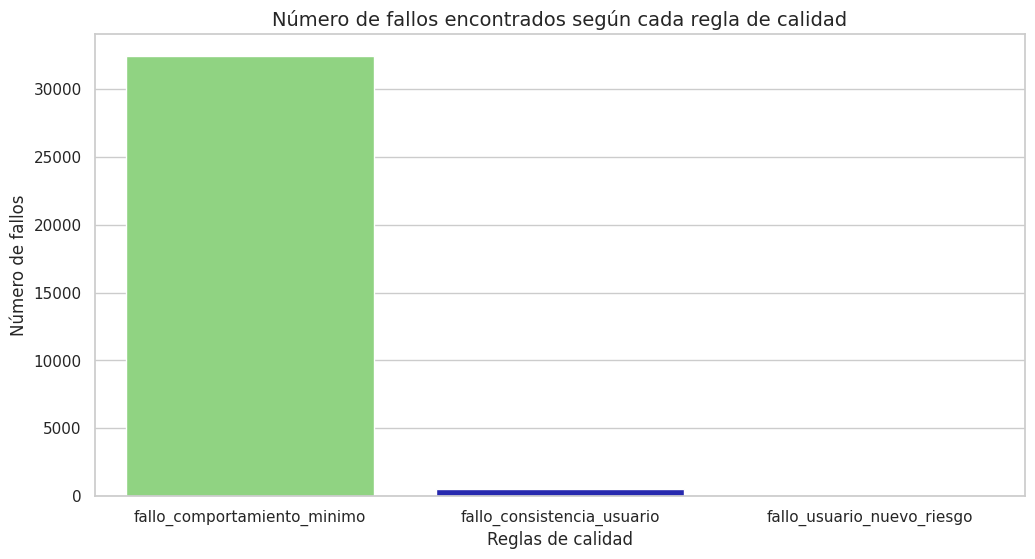


--- DISTRIBUCIÓN DE TRANSACCIONES FRAUDULENTAS (SOSPECHOSO VS. FIABLE) ---
+-------------+------------------------------+----------------+
|calidad_señal|num_transacciones_fraudulentas|porcentaje_total|
+-------------+------------------------------+----------------+
|   SOSPECHOSO|                          1202|           95.25|
|       FIABLE|                            60|            4.75|
+-------------+------------------------------+----------------+


--- CARACTERÍSTICAS PROMEDIO DE LAS TRANSACCIONES FRAUDULENTAS (SOSPECHOSO VS. FIABLE) ---
+-------------+--------------+-------------------------+---------------------------------+
|calidad_señal|monto_promedio|promedio_acciones_previas|promedio_urls_distintas_visitadas|
+-------------+--------------+-------------------------+---------------------------------+
|   SOSPECHOSO|       1754.13|                     0.01|                             0.01|
|       FIABLE|       1461.46|                      1.3|                           

DataFrame[user_id: bigint, id_transaccion: string, fecha_transaccion: timestamp, monto: double, metodo_pago: string, estado_limpio: string, confirmado_como_fraude: boolean, hora_transaccion: int, num_acciones_previas: bigint, urls_distintas_visitadas: bigint, numero_transacciones_por_usuario: bigint, monto_promedio_historico: double, desviacion_estandar_monto: double, fallo_comportamiento_minimo: boolean, fallo_consistencia_usuario: boolean, fallo_usuario_nuevo_riesgo: boolean, calidad_señal: string]

In [4]:
from pyspark.sql.functions import round
import matplotlib.pyplot as plt
import seaborn as sns

# Total de transacciones sospechosas
num_transacciones_sospechosas = df_validado_final.filter(col("calidad_señal") == "SOSPECHOSO").count()

# Transacciones sospechosas y fraudulentas
num_transacciones_fraudulentas_sospechosas = df_validado_final.filter(
    (col("calidad_señal") == "SOSPECHOSO") & (col("confirmado_como_fraude") == True)
).count()

# Transacciones sospechosas y no fraudulentas
num_transacciones_no_fraudulentas_sospechosas = df_validado_final.filter(
    (col("calidad_señal") == "SOSPECHOSO") & (col("confirmado_como_fraude") == False)
).count()

print(f"Número total de transacciones marcadas como sospechosas: {num_transacciones_sospechosas}")
print(f"Número de transacciones sospechosas y fraudulentas: {num_transacciones_fraudulentas_sospechosas}")
print(f"Número de transacciones sospechosas y no fraudulentas: {num_transacciones_no_fraudulentas_sospechosas}")

# Total de transacciones fraudulentas y no fraudulentas
total_fraudes = df_validado_final.filter(col("confirmado_como_fraude") == True).count()
total_no_fraudes = df_validado_final.filter(col("confirmado_como_fraude") == False).count()

# Porcentaje de transacciones fraudulentas que son sospechosas
porc_fraudes_sospechosas = (num_transacciones_fraudulentas_sospechosas / total_fraudes) * 100

# Porcentaje de transacciones no fraudulentas que son sospechosas
porc_no_fraudes_sospechosas = (num_transacciones_no_fraudulentas_sospechosas / total_no_fraudes) * 100

print(f"Porcentaje de transacciones fraudulentas que son sospechosas: {porc_fraudes_sospechosas:.2f}%")
print(f"Porcentaje de transacciones no fraudulentas que son sospechosas: {porc_no_fraudes_sospechosas:.2f}%")

# Visualizamos una tabla y un gráfico de barras que muestre el conteo de fallos para cada regla de calidad
print("\n--- DESGLOSE DE LAS TRANSACCIONES MARCADAS COMO SOSPECHOSAS SEGÚN LAS REGLAS DE CALIDAD ---")
df_resumen_validacion.show()
pd_resumen = df_resumen_validacion.toPandas()

# ¿Transacciones que son señaladas como SOSPECHOSAS por más de una regla a la vez?
df_multiples_reglas = df_validado_final.filter(
    (col("fallo_comportamiento_minimo").cast("int") +
     col("fallo_consistencia_usuario").cast("int") +
     col("fallo_usuario_nuevo_riesgo").cast("int")) > 1
)

# Mostrar las transacciones
print("\n--- TRANSACCIONES QUE SON SEÑALADAS COMO SOSPECHOSAS POR MÁS DE UNA REGLA A LA VEZ ---")
df_multiples_reglas.select(
    "id_transaccion",
    "user_id",
    "monto",
    "confirmado_como_fraude",
    "fallo_comportamiento_minimo", 
    "fallo_consistencia_usuario", 
    "fallo_usuario_nuevo_riesgo"
).show(truncate=False)

print("\n--- GRÁFICO DE BARRAS QUE MUESTRA LA DISTRIBUCIÓN DE LAS TRANSACCIONES SOSPECHOSAS ---")
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")
sns.barplot(
    x="regla_validada",
    y="numero_fallos_regla",
    data=pd_resumen,
    hue="regla_validada",
    palette=["#87E075", "#1014C4", "#E6D139"],
    legend=False
)
plt.title("Número de fallos encontrados según cada regla de calidad", fontsize=14)
plt.xlabel("Reglas de calidad", fontsize=12)
plt.ylabel("Número de fallos", fontsize=12)
plt.show()

df_fraudes = df_validado_final.filter(col("confirmado_como_fraude") == True).cache()

# Número y porcentaje de fraudes según "calidad_señal"
print("\n--- DISTRIBUCIÓN DE TRANSACCIONES FRAUDULENTAS (SOSPECHOSO VS. FIABLE) ---")
total_fraudes = df_fraudes.count()
df_fraudes.groupBy("calidad_señal") \
    .agg(
        count("*").alias("num_transacciones_fraudulentas")
    ).withColumn(
        "porcentaje_total",
        round((col("num_transacciones_fraudulentas") / total_fraudes) * 100, 2)
    ).show()

# Características promedio (ej. monto_promedio) de las transacciones "confirmado_como_fraude" que fueron marcadas como "FIABLE" vs. las que fueron marcadas como "SOSPECHOSA"
print("\n--- CARACTERÍSTICAS PROMEDIO DE LAS TRANSACCIONES FRAUDULENTAS (SOSPECHOSO VS. FIABLE) ---")
df_fraudes.groupBy("calidad_señal") \
    .agg(
        round(avg("monto"), 2).alias("monto_promedio"),
        round(avg("num_acciones_previas"), 2).alias("promedio_acciones_previas"),
        round(avg("urls_distintas_visitadas"), 2).alias("promedio_urls_distintas_visitadas")
    ).show()

# Transacciones que sí son "confirmado_como_fraude" y marcadas como SOSPECHOSAS por la calidad del dato
print("\n--- EJEMPLO DE TRANSACCIONES CONFIRMADAS COMO FRAUDE Y MARCADAS COMO SOSPECHOSAS ---")
df_validado_final.filter(
    (col("confirmado_como_fraude") == True) & (col("calidad_señal") == "SOSPECHOSO")
).select(
    "id_transaccion", 
    "user_id",
    "numero_transacciones_por_usuario",
    "monto", 
    "num_acciones_previas", 
    "urls_distintas_visitadas",
    "fallo_comportamiento_minimo",
    "fallo_consistencia_usuario",
    "fallo_usuario_nuevo_riesgo"
).orderBy(col("monto").desc()).show()

# Liberamos la caché de los DataFrames
df_fraudes.unpersist()
df_validado_final.unpersist()

## Insights Clave

### Transacciones sospechosas vs. totales

* Total de transacciones marcadas como SOSPECHOSO: **32.458**.
* De estas, **1.202 son fraudes** confirmados (un 95,25% del total de los fraudes) y **31.256 son no fraudulentas** (64,13% del total de las transacciones legítimas).
* Esto indica que **los comportamientos atípicos detectados por las reglas de calidad se relacionan más frecuentemente con transacciones fraudulentas que con transacciones legítimas**. Sin embargo, esto **no significa que las transacciones no fraudulentas estén mal clasificadas**, sino que presentan un comportamiento estadísticamente atípico o inusual según las reglas de negocio, lo que justifica que se señalen como “sospechosas” para un análisis más cuidadoso.

### Distribución según reglas de calidad

* *fallo_comportamiento_minimo*: 32.432 transacciones.
* *fallo_consistencia_usuario*: 552 transacciones.
* *fallo_usuario_nuevo_riesgo*: 0 transacciones.
* **526 transacciones activan más de una regla al mismo tiempo**, mostrando que, aunque la mayoría de los casos siguen siendo detectados por una sola regla, existe ya un solapamiento relevante entre ambas.

### Fraudes y calidad del dato

* De 1.262 fraudes confirmados: 1.202 (95,25%) son SOSPECHOSO y 60 (4,75%) son FIABLE.
* Las transacciones **SOSPECHOSO presentan un monto promedio más alto** (1.754,13€) y **una interacción mínima** con la plataforma.
* Las transacciones **FIABLE tienen un monto menor** (1461,46€) y **algo más de actividad previa**.

## ¿Ayuda nuestro sistema de calidad a separar mejor los fraudes?

Al analizar las transacciones confirmadas como fraude, se observa su distribución según la columna *calidad_señal*, que puede ser “SOSPECHOSO” o “FIABLE”:

* Los registros SOSPECHOSOS dentro de las transacciones fraudulentas presentan montos más altos y una interacción mínima con la plataforma (pocas acciones previas y pocas URLs visitadas), indicando que las reglas de calidad identifican correctamente transacciones con comportamiento atípico o potencialmente problemático.
* Por su parte, los fraudes clasificados como FIABLES tienen montos menores y actividad ligeramente superior, lo que muestra que sus datos son consistentes y no activan ninguna regla de alerta.

Esto demuestra que la columna *calidad_señal* no determina si una transacción es fraude, sino que **evalúa la anomalía del comportamiento dentro del dataset**. Sin embargo, **sí ayuda a separar mejor los fraudes más evidentes**, ya que un 95,25% de las transacciones fraudulentas se marcan como SOSPECHOSAS —un porcentaje muy alto—, mientras que solo un 4,75% de los fraudes son FIABLES. En comparación, un 64,13% de las transacciones no fraudulentas son señaladas como SOSPECHOSAS, lo que resalta que, si bien los comportamientos atípicos detectados por las reglas se concentran más entre los fraudes, también están presentes en una proporción muy significativa de las transacciones legítimas.

Los registros FRAUDE + FIABLE representan fraudes confirmados cuyos datos son consistentes y no muestran patrones atípicos detectables por las reglas de calidad. Esto indica que la veracidad del fraude no depende de desviaciones detectables, y que el sistema de reglas sirve para destacar únicamente anomalías que podrían influir en análisis futuros o en modelos predictivos.

Al observar la tabla de transacciones SOSPECHOSAS, se identifican patrones comunes: montos elevados (en los ejemplos de fraude, próximos o superiores a 2.900€) combinados con una interacción nula con la plataforma, y en la mayoría de los casos, activación conjunta de la regla de comportamiento mínimo y la regla de consistencia del usuario. Esto confirma que las reglas de calidad son efectivas para detectar comportamientos extremos o atípicos, facilitando un análisis más detallado de registros potencialmente problemáticos.

## Conclusión final

El análisis de las transacciones confirmadas como fraude evidencia que la columna *calidad_señal* no determina si una transacción es fraude, sino que mide el comportamiento atípico dentro del dataset. Los registros SOSPECHOSOS muestran montos altos y una interacción mínima con la plataforma, activando las reglas de calidad, mientras que los fraudes FIABLES tienen datos consistentes que no disparan alertas. De los **1.262 fraudes, un 95.25% son SOSPECHOSOS y un 4.75% FIABLES**, lo que indica que la inmensa mayoría de los fraudes se manifiestan mediante patrones estadísticamente anómalos. En contraste, un 64.13% de las transacciones no fraudulentas también son señaladas como SOSPECHOSAS, lo que pone de relieve que, aunque los comportamientos atípicos detectados por las reglas se concentran más entre los fraudes, su tasa de falsos positivos sobre transacciones legítimas es considerable.

En resumen, *calidad_señal* permite identificar datos potencialmente anómalos y destacar casos con comportamientos extremos o inconsistentes, ofreciendo valor para alimentar modelos predictivos. Su gran ventaja es que ahora captura prácticamente todos los fraudes confirmados (95.25%); su principal limitación es que, por sí sola, no discrimina con suficiente precisión entre comportamiento atípico fraudulento y comportamiento atípico legítimo, por lo que sería conveniente combinarla con reglas adicionales o con un modelo predictivo que afine esta clasificación.

# Fase 5: Diagrama de la Solución y Conclusiones

## ¿Qué tipo de transacción "sospechosa" fue la más frecuente según tu informe?

Según nuestro informe, la regla de calidad que más transacciones marcó como SOSPECHOSAS fue la **Regla de Comportamiento Mínimo (*fallo_comportamiento_minimo*)**, con **32.432 transacciones**, muy por encima de la Regla de Consistencia del Usuario (552) y de la Regla de Usuarios Nuevos (0). Esto significa que la inmensa mayoría de las transacciones atípicas corresponden a compras de importe elevado (superior a 500€) que **no van precedidas de ninguna actividad de navegación registrada en los 15 minutos previos (*num_acciones_previas == 0*)**.

Estas transacciones destacan dentro del dataset por su comportamiento estadísticamente inusual: la mayoría de los usuarios deja algún rastro de navegación (visitas a páginas de producto, carrito, etc.) antes de completar una compra, por lo que una compra de alto valor sin ninguna interacción previa rompe con ese patrón habitual. Sin embargo, esto no implica necesariamente fraude: de las 32.458 transacciones SOSPECHOSAS, solo 1.202 corresponden a fraudes confirmados, mientras que 31.256 son transacciones legítimas que simplemente comparten ese mismo patrón de "compra sin navegación previa registrada". Por ello se marcan como "SOSPECHOSAS": no porque se sepa que son fraude, sino porque su comportamiento se desvía de lo esperado y merece una revisión adicional.

## ¿Por qué es importante este pipeline de validación antes de entrenar un modelo de Machine Learning? ¿Qué problema podría causar si no se hiciera?

El pipeline de validación cumple un papel crítico porque permite identificar registros con comportamientos anómalos o inconsistentes que podrían "ensuciar" los datos si se entrenara directamente un modelo de Machine Learning. Sin este paso, el modelo podría aprender patrones incorrectos o sesgados, interpretando anomalías legítimas como ejemplos normales, o incluso considerando falsamente estas transacciones atípicas como indicativas de fraude.

Por ejemplo, transacciones de clientes que compran de manera rápida y directa, sin navegar previamente por la web (el patrón que activa la Regla de Comportamiento Mínimo), podrían ser consideradas atípicas por las reglas de calidad sin ser fraudulentas. Si estas transacciones se mezclaran con el resto sin señalizarse, el modelo podría aprender a tratar comportamientos válidos como sospechosos, reduciendo su capacidad de generalización y aumentando los falsos positivos.

Gracias al pipeline, se puede marcar la columna calidad_señal como "FIABLE" o "SOSPECHOSO", sin determinar si una transacción es fraude. Esta señal permite que el modelo distinga entre comportamientos normales y anomalías estadísticas, mejorando la calidad del aprendizaje y facilitando que los patrones de fraude reales sean más fáciles de detectar en el futuro.

Además, es importante destacar que **el modelo de Machine Learning necesita entrenarse utilizando también las transacciones marcadas como SOSPECHOSAS, sin eliminarlas del dataset**. Con los resultados del pipeline corregido esto resulta todavía más evidente: el 64.13% de las transacciones legítimas (no fraudulentas) son marcadas como SOSPECHOSAS, principalmente por la ausencia de actividad previa registrada. Si se eliminaran estos registros, se descartaría casi dos terceras partes de las transacciones legítimas del dataset, perdiendo información crucial sobre la diversidad real de comportamientos de compra y dejando al modelo con una muestra sesgada y poco representativa. Mantener estas transacciones —correctamente etiquetadas mediante calidad_señal— permite que el algoritmo aprenda a reconocer patrones atípicos tanto en transacciones fraudulentas como en no fraudulentas, evitando que confunda anomalías legítimas con fraude y permitiéndole generalizar correctamente a casos atípicos reales.

## Diagrama del pipeline de validación

Este podría ser el diagrama de la solución adoptada:

```mermaid
graph TD
    %% Los títulos de los subgrafos están simplificados para máxima compatibilidad.
    subgraph "FASE 1 - Configuración y Preparación de Datos (Output Módulo 2)"
        A["<b>Inicio - SparkSession</b><br>Inicia clúster local de Spark<br><i>SparkSession.builder.getOrCreate()</i>"]
        B["<b>Carga de Datos</b><br>Archivos Parquet:<br>- transacciones.parquet<br>- logs_web.parquet<br>Se crean DataFrames Spark"]
        C["<b>Join de Transacciones y Logs</b><br>Condición:<br>logs.user_id = transacciones.user_id<br>y fecha_log < fecha_transaccion<br>Se eliminan duplicados de user_id"]
        D["<b>Filtrado por Ventana Temporal</b><br>Solo logs ocurridos 15 minutos antes de la transacción"]
        E["<b>Agregación de Comportamiento</b><br>Por id_transaccion:<br>- num_acciones_previas<br>- urls_distintas_visitadas"]
        F["<b>DataFrame Final de Análisis</b><br>Se unen las métricas con el DataFrame de transacciones original<br>df_final_analisis"]
    end

    subgraph "FASE 2 - Definición de las Reglas de Calidad para las "Señales""
        G["<b>Definición de Reglas de Calidad</b"]
        G1["<b>Regla 1 - Comportamiento Mínimo</b><br>Transacción > 500€ sin acciones previas<br>→ comportamiento anómalo"]
        G2["<b>Regla 2 - Consistencia del Usuario</b><br>monto > media_historica + 3σ<br>→ desviación estadística"]
        G3["<b>Regla 3 - Usuario Nuevo de Riesgo</b><br>Transacción > 1000€ con 1 sola operación<br>→ patrón de fraude típico"]
    end

    subgraph "FASE 3 - Implementación del Pipeline de Validación"
        H["<b>Enriquecimiento del Dataset</b><br>- numero_transacciones_por_usuario (Window)<br>- Métricas históricas (media y desviación)<br>- Join con baseline"]
        I["<b>Aplicación de Reglas de Calidad</b><br>- Evaluación de condiciones<br>- Generación de flags booleanos"]
        J["<b>Generación de Señal de Calidad</b><br>- Consolidación de reglas<br>- Clasificación: SOSPECHOSO / FIABLE"]
        K["<b>Resultados del Pipeline</b><br>- Resumen de fallos por regla<br>- Dataset final validado (df_validado_final)"]
    end

    subgraph "FASE 4 - Generación de Resultados y Análisis de Impacto"
        O["<b>Métricas Globales y Porcentajes</b><br>- Total transacciones sospechosas<br>- % fraudes sospechosos<br>- % no fraudes sospechosos"]
        P["<b>Análisis por Reglas de Calidad</b><br>- Conteo de fallos por regla<br>- Distribución de transacciones sospechosas"]
        Q["<b>Análisis de Casos Complejos</b><br>- Transacciones con múltiples reglas activadas"]
        R["<b>Análisis de Fraudes</b><br>- Distribución SOSPECHOSO vs FIABLE<br>- Características promedio (monto, actividad)"]
        S["<b>Inspección de Casos Reales</b><br>- Ejemplos de fraudes sospechosos"]
    end

    %% Conexiones del Flujo Principal
    A --> B
    B --> C
    C --> D
    D --> E
    E --> F
    F --> G

    G --> G1
    G --> G2
    G --> G3
    
    G --> H
    H --> I
    I --> J
    J --> K
    K --> O
    O --> P
    P --> Q
    Q --> R
    R --> S
    
    %% Estilos
    classDef fase1 fill:#D4F1F9,stroke:#0B7285,stroke-width:2px;
    classDef fase2 fill:#FFF3BF,stroke:#E67700,stroke-width:2px;
    classDef fase3 fill:#E5DBFF,stroke:#5F3DC4,stroke-width:2px;
    classDef fase4 fill:#FFD6E0,stroke:#C2255C,stroke-width:2px;

    class A,B,C,D,E,F fase1;
    class G,G1,G2,G3 fase2;
    class H,I,J,K fase3;
    class O,P,Q,R,S fase4;
```

### Explicación del Diagrama

Este diagrama representa el flujo completo de procesamiento, validación y análisis de datos para detectar **comportamientos atípicos** en transacciones, diferenciando entre la calidad del dato (anomalía) y la confirmación real de fraude, utilizando procesamiento distribuido con Apache Spark.

### Fase 1: Configuración y Preparación de Datos

El proceso comienza con la inicialización de una **SparkSession**, que levanta un clúster local para trabajar con grandes volúmenes de datos de forma distribuida.

A continuación:

* Se cargan los datasets desde el Data Lake en formato Parquet (transacciones y logs de navegación).
* Se realiza un JOIN entre ambos datasets utilizando el *user_id* y filtrando únicamente los logs que ocurrieron antes de cada transacción.
* Se aplica un **filtrado temporal** para quedarnos con las interacciones de los últimos 15 minutos previos a la transacción.
* Se lleva a cabo un proceso de **Feature Engineering**, donde se calculan métricas clave como:
    * Número de acciones previas del usuario.
    * Número de URLs distintas visitadas.

El resultado es un DataFrame enriquecido (*df_final_analisis*), que combina información transaccional con comportamiento del usuario.

### Fase 2: Definición de las Reglas de Calidad

En esta fase se definen las reglas que permitirán identificar comportamientos atípicos o anómalos dentro del dataset. Estas reglas no determinan si existe fraude, sino que evalúan la coherencia del comportamiento:


* **Comportamiento mínimo**: Transacciones de alto valor sin actividad previa.
* **Consistencia del usuario**: Desviaciones significativas respecto al comportamiento histórico.
* **Usuarios nuevos de riesgo**: Transacciones elevadas en usuarios sin historial.

El objetivo aquí es construir una base lógica para detectar señales sospechosas desde el punto de vista estadístico y de negocio.

### Fase 3: Implementación del Pipeline de Validación

En esta fase se aplica el pipeline de validación sobre los datos enriquecidos:

* Se añaden nuevas features como el número de transacciones por usuario.
* Se calcula una línea base histórica (media y desviación estándar por usuario), que permite contextualizar cada transacción.
* Se aplican las reglas de calidad definidas, generando columnas booleanas que indican si cada regla se incumple.
* Se consolida toda esta información en una nueva variable: *calidad_señal*, que clasifica cada transacción como:
    * **SOSPECHOSO** → si presenta algún comportamiento anómalo.
    * **FIABLE** → si su comportamiento es consistente.

El resultado es un dataset validado (*df_validado_final*), listo para análisis o para alimentar modelos de Machine Learning.

### Fase 4: Generación de Resultados y Análisis de Impacto

Finalmente, se realiza el análisis para extraer valor de los datos:

* Se calculan métricas globales y porcentajes que permiten entender:
    * Cuántas transacciones son sospechosas.
    * Qué proporción de fraudes presenta comportamientos anómalos.
* Se analiza el impacto de cada regla de calidad, identificando cuáles detectan más casos.
* Se detectan transacciones complejas que activan múltiples reglas simultáneamente.
* Se estudia la distribución de los fraudes según su calidad (SOSPECHOSO vs FIABLE).
* Se analizan características promedio (monto, actividad previa) para identificar patrones.
* Se inspeccionan casos reales para validar los resultados.